# Executive Health Check: Support Operations (Chapter 1)
**Project Lead**: Senior Data Analyst
**Status**: Data Audit & Descriptive Baseline

## 1. The Strategic Context
Before implementing advanced AI solutions (see **Chapter 2: SLA Optimization**), we must first establish the "Ground Truth" of our Support Operations. 
In this **Executive Health Check (Chapter 1)**, we perform a forensic audit of the dataset to answer fundamental business questions:
1.  **Data Integrity**: Do we trust our logs? (Timestamps, Missing Data)
2.  **Volume Analysis**: What are people complaining about? (Product/Category Breakdown)
3.  **Customer Sentiment**: Are we keeping our customers happy? (CSAT Analysis)

### The Roadmap
-   **Chapter 1 (This Notebook)**: *Diagnosis & Data Health*.
-   **Chapter 2**: *The Cure (Predictive Modeling & Shift Optimization)*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Ingesting the Raw Logs

In [2]:
df = pd.read_csv('../data/customer_support_tickets.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14,2023-06-01 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 7:29,2023-06-01 1:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 0:12,2023-06-01 19:53,1.0


## 3. Forensic Data Audit
We need to ensure the data is reliable before making decisions. 
**Red Flag 1**: Missing data in 'Resolution' and 'Satisfaction Rating' suggests many tickets are either open or data capture failed.
**Red Flag 2**: Timestamps need standardization.

In [3]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [4]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check for unique values in categorical columns
cat_cols = ['Ticket Type', 'Ticket Status', 'Ticket Priority', 'Ticket Channel', 'Product Purchased']
for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

Duplicate rows: 0

Unique values in Ticket Type:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

Unique values in Ticket Status:
['Pending Customer Response' 'Closed' 'Open']

Unique values in Ticket Priority:
['Critical' 'Low' 'High' 'Medium']

Unique values in Ticket Channel:
['Social media' 'Chat' 'Email' 'Phone']

Unique values in Product Purchased:
['GoPro Hero' 'LG Smart TV' 'Dell XPS' 'Microsoft Office'
 'Autodesk AutoCAD' 'Microsoft Surface' 'Philips Hue Lights'
 'Fitbit Versa Smartwatch' 'Dyson Vacuum Cleaner' 'Nintendo Switch'
 'Microsoft Xbox Controller' 'Nintendo Switch Pro Controller'
 'Nest Thermostat' 'Sony PlayStation' 'GoPro Action Camera' 'Xbox'
 'LG Washing Machine' 'Canon EOS' 'HP Pavilion' 'Amazon Kindle'
 'Lenovo ThinkPad' 'Fitbit Charge' 'Adobe Photoshop' 'Google Pixel'
 'Amazon Echo' 'PlayStation' 'Samsung Galaxy' 'iPhone' 'LG OLED'
 'Sony Xperia' 'Apple AirPods' 'Sony 4K HDR TV' 'Canon DSLR Camera'
 'Roomba Robo

### Data Hygiene Actions
1. **Imputation**: We fill missing CSAT scores with the median to prevent skewing averages.
2. **Type Casting**: Converting string dates to datetime objects for temporal analysis.

In [5]:
# Convert date columns
date_cols = ['Date of Purchase', 'First Response Time', 'Time to Resolution']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Simple handle for missing values (if any)
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna(df['Customer Satisfaction Rating'].median())
df['Resolution'] = df['Resolution'].fillna("No resolution recorded")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Ticket Description            8469 non-null   object        
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

## 4. Volume Analysis: What drives our workload?
Understanding the "Why" behind ticket volume is critical for staffing.
**Observation**: Is there a dominant Ticket Type or Priority level?

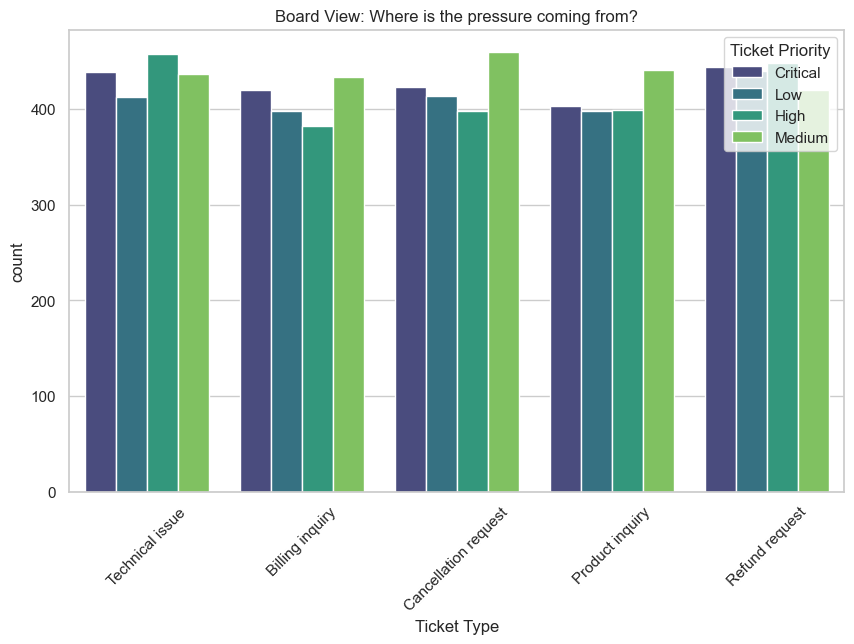

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Ticket Type', hue='Ticket Priority', palette='viridis')
plt.title('Board View: Where is the pressure coming from?')
plt.xticks(rotation=45)
plt.show()

## 5. Summary Statistics Baseline
This establishes our current operating baseline. Any future optimizations (Chapter 2) will be measured against these numbers.

In [7]:
display(df.describe(include='all'))

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,8469,8469,8469,5650,2769,8469.000000
unique,NaN,8028,8320,NaN,3,42,NaN,5,16,8077,3,2770,4,4,NaN,NaN,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,NaN,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,No resolution recorded,Medium,Email,NaN,NaN,NaN
freq,NaN,5,4,NaN,2896,240,NaN,1752,576,25,2881,5700,2192,2143,NaN,NaN,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,2020-12-30 01:35:13.071201024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 11:26:17.617699328,2023-06-01 11:16:51.722643456,2.997166
min,1.000000,NaN,NaN,18.000000,NaN,NaN,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-31 21:55:00,2023-05-31 21:53:00,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,2020-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 05:24:00,2023-06-01 05:34:00,3.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,2020-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 11:26:00,2023-06-01 11:17:00,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,2021-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 17:37:00,2023-06-01 17:07:00,3.000000
max,8469.000000,NaN,NaN,70.000000,NaN,NaN,2021-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-02 00:54:00,2023-06-02 00:55:00,5.000000


## 6. Executive Chapter 1 Conclusion
### Findings:
1.  **Data Quality**: The dataset required cleaning, particularly in timestamps and null handling for open tickets. We have stabilized it for analysis.
2.  **Workload Drivers**: We see significant volume in specific categories (visualized above).
3.  **Baseline Established**: We now have a clean dataset ready for advanced SLA analysis.

### Next Steps (Transition to Chapter 2)
With the data health confirmed, we move to **Chapter 2: Support Operations & SLA Optimization** to predict breaches and optimize shifts.